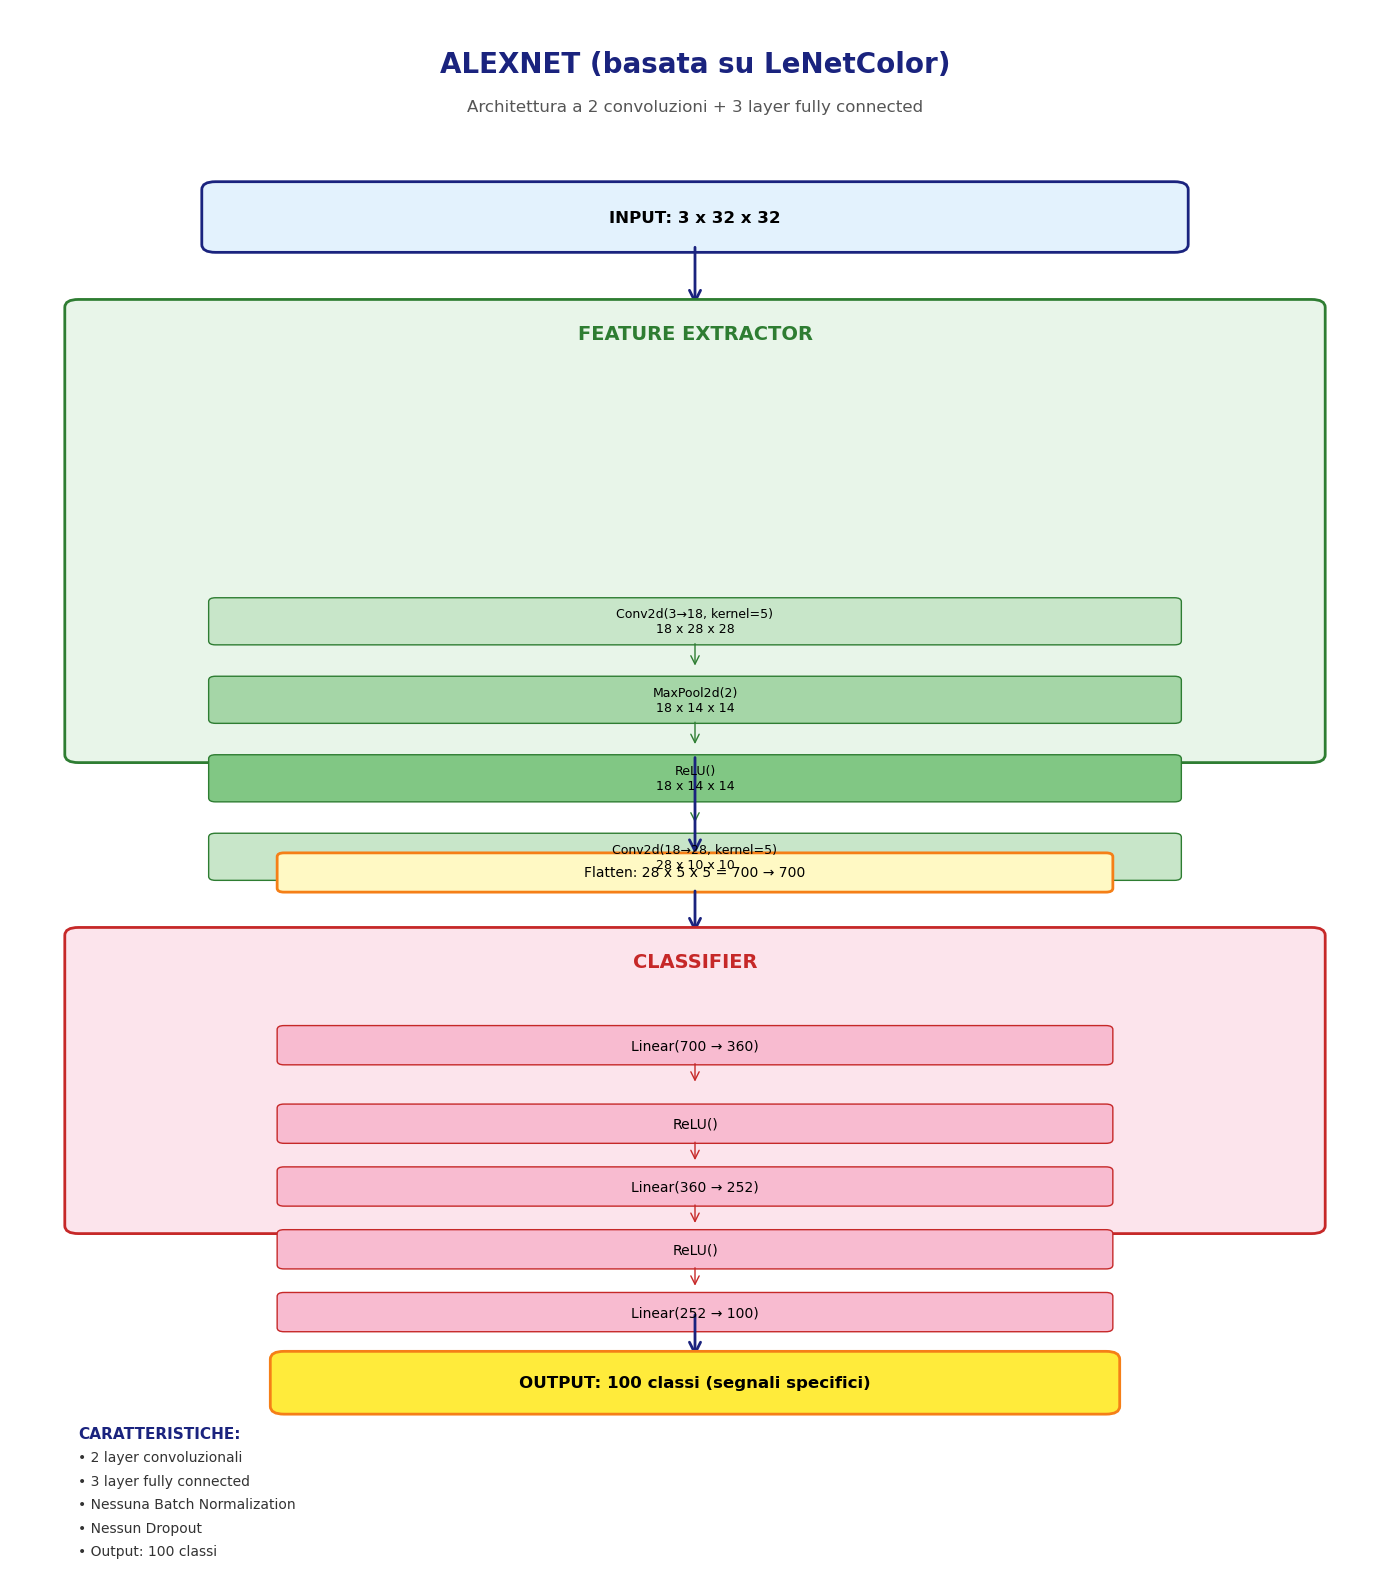

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(14, 16))
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis('off')

# Titolo
ax.text(5, 19.2, 'ALEXNET (basata su LeNetColor)', fontsize=20, fontweight='bold', ha='center', color='#1a237e')

# Sottotitolo
ax.text(5, 18.7, 'Architettura a 2 convoluzioni + 3 layer fully connected', fontsize=12, ha='center', color='#555')

# --- INPUT ---
rect_input = FancyBboxPatch((1.5, 17.0), 7, 0.7, boxstyle="round,pad=0.1", 
                            facecolor='#e3f2fd', edgecolor='#1a237e', linewidth=2)
ax.add_patch(rect_input)
ax.text(5, 17.35, 'INPUT: 3 x 32 x 32', fontsize=12, ha='center', va='center', fontweight='bold')

# Freccia input -> FE
arrow = FancyArrowPatch((5, 17.0), (5, 16.2), arrowstyle='->', mutation_scale=20, 
                        color='#1a237e', linewidth=2)
ax.add_patch(arrow)

# --- FEATURE EXTRACTOR ---
box_fe = FancyBboxPatch((0.5, 10.5), 9, 5.7, boxstyle="round,pad=0.1", 
                        facecolor='#e8f5e9', edgecolor='#2e7d32', linewidth=2)
ax.add_patch(box_fe)
ax.text(5, 15.8, 'FEATURE EXTRACTOR', fontsize=14, fontweight='bold', ha='center', color='#2e7d32')

# Layer all'interno di FE
layers_fe = [
    ('Conv2d(3→18, kernel=5)', 13.5, '18 x 28 x 28'),
    ('MaxPool2d(2)', 12.5, '18 x 14 x 14'),
    ('ReLU()', 11.5, '18 x 14 x 14'),
    ('Conv2d(18→28, kernel=5)', 10.5, '28 x 10 x 10'),
    ('MaxPool2d(2)', 9.5, '28 x 5 x 5'),
    ('ReLU()', 8.5, '28 x 5 x 5')
]

for i, (label, y_pos, dim) in enumerate(layers_fe):
    y_pos_adjusted = y_pos - 1.3
    if y_pos_adjusted < 9.0:
        continue
    color = '#c8e6c9' if 'Conv' in label else '#a5d6a7' if 'MaxPool' in label else '#81c784'
    box = FancyBboxPatch((1.5, y_pos_adjusted - 0.25), 7, 0.5, 
                         boxstyle="round,pad=0.05", facecolor=color, edgecolor='#2e7d32')
    ax.add_patch(box)
    ax.text(5, y_pos_adjusted, f'{label}\n{dim}', fontsize=9, ha='center', va='center')

    if y_pos_adjusted > 9.5:
        arrow = FancyArrowPatch((5, y_pos_adjusted - 0.25), (5, y_pos_adjusted - 0.6), 
                                arrowstyle='->', mutation_scale=15, color='#2e7d32')
        ax.add_patch(arrow)

# Freccia FE -> Classifier
arrow = FancyArrowPatch((5, 10.5), (5, 9.2), arrowstyle='->', mutation_scale=20, 
                        color='#1a237e', linewidth=2)
ax.add_patch(arrow)

# Flatten
box_flatten = FancyBboxPatch((2.0, 8.8), 6, 0.4, boxstyle="round,pad=0.05",
                             facecolor='#fff9c4', edgecolor='#f57f17', linewidth=2)
ax.add_patch(box_flatten)
ax.text(5, 9.0, 'Flatten: 28 x 5 x 5 = 700 → 700', fontsize=10, ha='center', va='center')

arrow = FancyArrowPatch((5, 8.8), (5, 8.2), arrowstyle='->', mutation_scale=20, 
                        color='#1a237e', linewidth=2)
ax.add_patch(arrow)

# --- CLASSIFIER ---
box_cl = FancyBboxPatch((0.5, 4.5), 9, 3.7, boxstyle="round,pad=0.1", 
                        facecolor='#fce4ec', edgecolor='#c62828', linewidth=2)
ax.add_patch(box_cl)
ax.text(5, 7.8, 'CLASSIFIER', fontsize=14, fontweight='bold', ha='center', color='#c62828')

layers_cl = [
    ('Linear(700 → 360)', 6.8),
    ('ReLU()', 5.8),
    ('Linear(360 → 252)', 5.0),
    ('ReLU()', 4.2),
    ('Linear(252 → 100)', 3.4)
]

for label, y_pos in layers_cl:
    box = FancyBboxPatch((2.0, y_pos - 0.2), 6, 0.4, 
                         boxstyle="round,pad=0.05", facecolor='#f8bbd0', edgecolor='#c62828')
    ax.add_patch(box)
    ax.text(5, y_pos, label, fontsize=10, ha='center', va='center')

    if y_pos > 4.0:
        arrow = FancyArrowPatch((5, y_pos - 0.2), (5, y_pos - 0.5), 
                                arrowstyle='->', mutation_scale=15, color='#c62828')
        ax.add_patch(arrow)

# Freccia Classifier -> Output
arrow = FancyArrowPatch((5, 3.4), (5, 2.8), arrowstyle='->', mutation_scale=20, 
                        color='#1a237e', linewidth=2)
ax.add_patch(arrow)

# OUTPUT
rect_output = FancyBboxPatch((2.0, 2.2), 6, 0.6, boxstyle="round,pad=0.1", 
                             facecolor='#ffeb3b', edgecolor='#f57f17', linewidth=2)
ax.add_patch(rect_output)
ax.text(5, 2.5, 'OUTPUT: 100 classi (segnali specifici)', fontsize=12, ha='center', va='center', fontweight='bold')

# Legenda caratteristiche
ax.text(0.5, 1.8, 'CARATTERISTICHE:', fontsize=11, fontweight='bold', color='#1a237e')
ax.text(0.5, 1.5, '• 2 layer convoluzionali', fontsize=10, color='#333')
ax.text(0.5, 1.2, '• 3 layer fully connected', fontsize=10, color='#333')
ax.text(0.5, 0.9, '• Nessuna Batch Normalization', fontsize=10, color='#333')
ax.text(0.5, 0.6, '• Nessun Dropout', fontsize=10, color='#333')
ax.text(0.5, 0.3, '• Output: 100 classi', fontsize=10, color='#333')

plt.tight_layout()
plt.savefig('alexnet_diagram.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(1, 1, figsize=(14, 20))
ax.set_xlim(0, 10)
ax.set_ylim(0, 24)
ax.axis('off')

# Titolo
ax.text(5, 23.2, 'MINIALEXNET', fontsize=20, fontweight='bold', ha='center', color='#1a237e')

# Sottotitolo
ax.text(5, 22.7, 'Architettura a 5 convoluzioni + 3 layer fully connected', fontsize=12, ha='center', color='#555')

# --- INPUT ---
rect_input = FancyBboxPatch((1.5, 21.0), 7, 0.7, boxstyle="round,pad=0.1", 
                            facecolor='#e3f2fd', edgecolor='#1a237e', linewidth=2)
ax.add_patch(rect_input)
ax.text(5, 21.35, 'INPUT: 3 x 32 x 32', fontsize=12, ha='center', va='center', fontweight='bold')

arrow = FancyArrowPatch((5, 21.0), (5, 20.2), arrowstyle='->', mutation_scale=20, color='#1a237e', linewidth=2)
ax.add_patch(arrow)

# --- FEATURE EXTRACTOR ---
box_fe = FancyBboxPatch((0.5, 11.5), 9, 8.7, boxstyle="round,pad=0.1", 
                        facecolor='#e8f5e9', edgecolor='#2e7d32', linewidth=2)
ax.add_patch(box_fe)
ax.text(5, 19.8, 'FEATURE EXTRACTOR', fontsize=14, fontweight='bold', ha='center', color='#2e7d32')

layers_fe = [
    ('Conv2d(3→16, k=5, p=2)', 18.5, '16 x 32 x 32'),
    ('MaxPool2d(2)', 17.5, '16 x 16 x 16'),
    ('ReLU()', 16.5, '16 x 16 x 16'),
    ('Conv2d(16→32, k=5, p=2)', 15.5, '32 x 16 x 16'),
    ('MaxPool2d(2)', 14.5, '32 x 8 x 8'),
    ('ReLU()', 13.5, '32 x 8 x 8'),
    ('Conv2d(32→64, k=3, p=1)', 12.5, '64 x 8 x 8'),
    ('ReLU()', 11.5, '64 x 8 x 8'),
    ('Conv2d(64→128, k=3, p=1)', 10.5, '128 x 8 x 8'),
    ('ReLU()', 9.5, '128 x 8 x 8'),
    ('Conv2d(128→256, k=3, p=1)', 8.5, '256 x 8 x 8'),
    ('MaxPool2d(2)', 7.5, '256 x 4 x 4'),
    ('ReLU()', 6.5, '256 x 4 x 4')
]

for label, y_pos, dim in layers_fe:
    color = '#c8e6c9' if 'Conv' in label else '#a5d6a7' if 'MaxPool' in label else '#81c784'
    box = FancyBboxPatch((1.5, y_pos - 0.25), 7, 0.5, 
                         boxstyle="round,pad=0.05", facecolor=color, edgecolor='#2e7d32')
    ax.add_patch(box)
    ax.text(5, y_pos, f'{label}\n{dim}', fontsize=8, ha='center', va='center')

    if y_pos > 7.0:
        arrow = FancyArrowPatch((5, y_pos - 0.25), (5, y_pos - 0.6), 
                                arrowstyle='->', mutation_scale=15, color='#2e7d32')
        ax.add_patch(arrow)

# Freccia FE -> Classifier
arrow = FancyArrowPatch((5, 6.5), (5, 5.7), arrowstyle='->', mutation_scale=20, color='#1a237e', linewidth=2)
ax.add_patch(arrow)

# Flatten
box_flatten = FancyBboxPatch((2.0, 5.3), 6, 0.4, boxstyle="round,pad=0.05",
                             facecolor='#fff9c4', edgecolor='#f57f17', linewidth=2)
ax.add_patch(box_flatten)
ax.text(5, 5.5, 'Flatten: 256 x 4 x 4 = 4096 → 4096', fontsize=10, ha='center', va='center')

arrow = FancyArrowPatch((5, 5.3), (5, 4.7), arrowstyle='->', mutation_scale=20, color='#1a237e', linewidth=2)
ax.add_patch(arrow)

# --- CLASSIFIER ---
box_cl = FancyBboxPatch((0.5, 2.5), 9, 2.2, boxstyle="round,pad=0.1", 
                        facecolor='#fce4ec', edgecolor='#c62828', linewidth=2)
ax.add_patch(box_cl)
ax.text(5, 4.3, 'CLASSIFIER', fontsize=14, fontweight='bold', ha='center', color='#c62828')

layers_cl = [
    ('Linear(4096 → 2048)', 3.7),
    ('ReLU()', 3.0),
    ('Linear(2048 → 1024)', 2.3),
    ('ReLU()', 1.6),
    ('Linear(1024 → 4)', 0.9)
]

for label, y_pos in layers_cl:
    box = FancyBboxPatch((2.0, y_pos - 0.2), 6, 0.4, 
                         boxstyle="round,pad=0.05", facecolor='#f8bbd0', edgecolor='#c62828')
    ax.add_patch(box)
    ax.text(5, y_pos, label, fontsize=9, ha='center', va='center')

    if y_pos > 1.2:
        arrow = FancyArrowPatch((5, y_pos - 0.2), (5, y_pos - 0.5), 
                                arrowstyle='->', mutation_scale=15, color='#c62828')
        ax.add_patch(arrow)

# Freccia Classifier -> Output
arrow = FancyArrowPatch((5, 0.9), (5, 0.3), arrowstyle='->', mutation_scale=20, color='#1a237e', linewidth=2)
ax.add_patch(arrow)

# OUTPUT
rect_output = FancyBboxPatch((1.5, -0.3), 7, 0.6, boxstyle="round,pad=0.1", 
                             facecolor='#ffeb3b', edgecolor='#f57f17', linewidth=2)
ax.add_patch(rect_output)
ax.text(5, 0.0, 'OUTPUT: 4 classi (Indicazione, Pericolo, Divieto, Background)', 
        fontsize=10, ha='center', va='center', fontweight='bold')

# Legenda caratteristiche (posizionata in basso)
ax.text(0.5, -1.0, 'CARATTERISTICHE:', fontsize=11, fontweight='bold', color='#1a237e')
ax.text(0.5, -1.3, '• 5 layer convoluzionali', fontsize=10, color='#333')
ax.text(0.5, -1.6, '• 3 layer fully connected', fontsize=10, color='#333')
ax.text(0.5, -1.9, '• Nessuna Batch Normalization', fontsize=10, color='#333')
ax.text(0.5, -2.2, '• Nessun Dropout', fontsize=10, color='#333')
ax.text(0.5, -2.5, '• Output: 4 classi (macrocategorie)', fontsize=10, color='#333')

plt.tight_layout()
plt.savefig('minialexnet_diagram.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(1, 1, figsize=(14, 22))
ax.set_xlim(0, 10)
ax.set_ylim(0, 26)
ax.axis('off')

# Titolo
ax.text(5, 25.2, 'MINIALEXNETV2', fontsize=20, fontweight='bold', ha='center', color='#1a237e')

# Sottotitolo
ax.text(5, 24.7, 'Architettura migliorata con Batch Normalization e Dropout', fontsize=12, ha='center', color='#555')

# --- INPUT ---
rect_input = FancyBboxPatch((1.5, 23.0), 7, 0.7, boxstyle="round,pad=0.1", 
                            facecolor='#e3f2fd', edgecolor='#1a237e', linewidth=2)
ax.add_patch(rect_input)
ax.text(5, 23.35, 'INPUT: 3 x 32 x 32', fontsize=12, ha='center', va='center', fontweight='bold')

arrow = FancyArrowPatch((5, 23.0), (5, 22.2), arrowstyle='->', mutation_scale=20, color='#1a237e', linewidth=2)
ax.add_patch(arrow)

# --- FEATURE EXTRACTOR ---
box_fe = FancyBboxPatch((0.5, 12.5), 9, 9.7, boxstyle="round,pad=0.1", 
                        facecolor='#e8f5e9', edgecolor='#2e7d32', linewidth=2)
ax.add_patch(box_fe)
ax.text(5, 21.8, 'FEATURE EXTRACTOR', fontsize=14, fontweight='bold', ha='center', color='#2e7d32')

layers_fe = [
    ('Conv2d(3→16, k=5, p=2)', 20.5, '16 x 32 x 32'),
    ('MaxPool2d(2)', 19.5, '16 x 16 x 16'),
    ('ReLU()', 18.5, '16 x 16 x 16'),
    ('⭐ BatchNorm2d(16)', 17.7, '16 x 16 x 16'),
    ('Conv2d(16→32, k=5, p=2)', 16.8, '32 x 16 x 16'),
    ('MaxPool2d(2)', 15.8, '32 x 8 x 8'),
    ('ReLU()', 14.8, '32 x 8 x 8'),
    ('⭐ BatchNorm2d(32)', 14.0, '32 x 8 x 8'),
    ('Conv2d(32→64, k=3, p=1)', 13.1, '64 x 8 x 8'),
    ('ReLU()', 12.1, '64 x 8 x 8'),
    ('⭐ BatchNorm2d(64)', 11.3, '64 x 8 x 8'),
    ('Conv2d(64→128, k=3, p=1)', 10.4, '128 x 8 x 8'),
    ('ReLU()', 9.4, '128 x 8 x 8'),
    ('⭐ BatchNorm2d(128)', 8.6, '128 x 8 x 8'),
    ('Conv2d(128→256, k=3, p=1)', 7.7, '256 x 8 x 8'),
    ('MaxPool2d(2)', 6.7, '256 x 4 x 4'),
    ('ReLU()', 5.7, '256 x 4 x 4')
]

for label, y_pos, dim in layers_fe:
    is_bn = 'BatchNorm' in label
    color = '#fff9c4' if is_bn else '#c8e6c9' if 'Conv' in label else '#a5d6a7' if 'MaxPool' in label else '#81c784'
    edge = '#f57f17' if is_bn else '#2e7d32'
    box = FancyBboxPatch((1.5, y_pos - 0.25), 7, 0.5, 
                         boxstyle="round,pad=0.05", facecolor=color, edgecolor=edge, linewidth=1.5 if is_bn else 1)
    ax.add_patch(box)
    ax.text(5, y_pos, f'{label}\n{dim}', fontsize=7.5 if is_bn else 8, ha='center', va='center', 
            fontweight='bold' if is_bn else 'normal')

    if y_pos > 6.2:
        arrow = FancyArrowPatch((5, y_pos - 0.25), (5, y_pos - 0.6), 
                                arrowstyle='->', mutation_scale=15, color='#2e7d32')
        ax.add_patch(arrow)

# Freccia FE -> Classifier
arrow = FancyArrowPatch((5, 5.7), (5, 4.9), arrowstyle='->', mutation_scale=20, color='#1a237e', linewidth=2)
ax.add_patch(arrow)

# Flatten
box_flatten = FancyBboxPatch((2.0, 4.5), 6, 0.4, boxstyle="round,pad=0.05",
                             facecolor='#fff9c4', edgecolor='#f57f17', linewidth=2)
ax.add_patch(box_flatten)
ax.text(5, 4.7, 'Flatten: 256 x 4 x 4 = 4096 → 4096', fontsize=10, ha='center', va='center')

arrow = FancyArrowPatch((5, 4.5), (5, 3.9), arrowstyle='->', mutation_scale=20, color='#1a237e', linewidth=2)
ax.add_patch(arrow)

# --- CLASSIFIER ---
box_cl = FancyBboxPatch((0.5, 0.5), 9, 3.4, boxstyle="round,pad=0.1", 
                        facecolor='#fce4ec', edgecolor='#c62828', linewidth=2)
ax.add_patch(box_cl)
ax.text(5, 3.6, 'CLASSIFIER', fontsize=14, fontweight='bold', ha='center', color='#c62828')

layers_cl = [
    ('⭐ Dropout(p=0.5)', 3.0),
    ('⭐ BatchNorm1d(4096)', 2.3),
    ('Linear(4096 → 2048)', 1.6),
    ('ReLU()', 0.9),
    ('⭐ Dropout(p=0.5)', 0.2),
    ('⭐ BatchNorm1d(2048)', -0.5),
    ('Linear(2048 → 1024)', -1.2),
    ('ReLU()', -1.9),
    ('⭐ BatchNorm1d(1024)', -2.6),
    ('Linear(1024 → 4)', -3.3)
]

for label, y_pos in layers_cl:
    is_special = 'Dropout' in label or 'BatchNorm' in label
    color = '#fff9c4' if is_special else '#f8bbd0'
    edge = '#f57f17' if is_special else '#c62828'
    box = FancyBboxPatch((2.0, y_pos - 0.2), 6, 0.4, 
                         boxstyle="round,pad=0.05", facecolor=color, edgecolor=edge, linewidth=1.5 if is_special else 1)
    ax.add_patch(box)
    ax.text(5, y_pos, label, fontsize=8 if is_special else 9, ha='center', va='center', 
            fontweight='bold' if is_special else 'normal')

    if y_pos > -3.0:
        arrow = FancyArrowPatch((5, y_pos - 0.2), (5, y_pos - 0.5), 
                                arrowstyle='->', mutation_scale=15, color='#c62828')
        ax.add_patch(arrow)

# Freccia Classifier -> Output
arrow = FancyArrowPatch((5, -3.3), (5, -4.0), arrowstyle='->', mutation_scale=20, color='#1a237e', linewidth=2)
ax.add_patch(arrow)

# OUTPUT
rect_output = FancyBboxPatch((1.5, -4.6), 7, 0.6, boxstyle="round,pad=0.1", 
                             facecolor='#ffeb3b', edgecolor='#f57f17', linewidth=2)
ax.add_patch(rect_output)
ax.text(5, -4.3, 'OUTPUT: 4 classi (Indicazione, Pericolo, Divieto, Background)', 
        fontsize=10, ha='center', va='center', fontweight='bold')

# Legenda caratteristiche
ax.text(0.5, -5.5, 'CARATTERISTICHE:', fontsize=11, fontweight='bold', color='#1a237e')
ax.text(0.5, -5.8, '• 5 layer convoluzionali', fontsize=10, color='#333')
ax.text(0.5, -6.1, '• 3 layer fully connected', fontsize=10, color='#333')
ax.text(0.5, -6.4, '• ⭐ Batch Normalization (dopo ReLU nei layer conv e FC)', fontsize=10, color='#333')
ax.text(0.5, -6.7, '• ⭐ Dropout (prima dei layer fully connected)', fontsize=10, color='#333')
ax.text(0.5, -7.0, '• Output: 4 classi (macrocategorie)', fontsize=10, color='#333')
ax.text(0.5, -7.3, '• Maggiore capacità di generalizzazione e riduzione overfitting', fontsize=10, color='#333')

plt.tight_layout()
plt.savefig('minialexnetv2_diagram.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()